# acai.pdf_to_json — PyMuPDF Adapter Demo

This notebook exercises the **PyMuPdfParser** adapter (PyMuPDF / fitz + pdfplumber).

| Component | Name |
|-----------|------|
| **Port** | `PdfParserPort` (`parse_file`, `parse_bytes`) |
| **Domain** | `ParsedPdfDocument`, `PdfPage`, `PdfPageElement`, `PdfTextBlock`, `PdfImage`, `PdfTable` |
| **Adapter** | `PyMuPdfParser` — PyMuPDF (fitz) + pdfplumber |
| **Factory** | `create_pdf_parser(logger)` |

Sample PDFs are loaded from `_test/fixtures/` (shared between tests and examples).

In [1]:
PDF_FILE_NAME = "24030-03_06072004.pdf"

## 1 — Setup & Imports

In [2]:
from pathlib import Path
import json
import sys

# Ensure the local package root is importable in notebooks.
cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "lib" / "acai").exists()),
    None,
 )
if project_root is None:
    raise RuntimeError("Could not locate project root containing 'lib/acai'.")

lib_path = project_root / "lib"
if str(lib_path) not in sys.path:
    sys.path.insert(0, str(lib_path))

from acai.logging import LoggerConfig, LogLevel, create_logger
from acai.pdf_to_json import (
    ContentType,
    PdfParserConfig,
    create_pdf_parser,
 )

logger = create_logger(LoggerConfig(service_name="pdf-demo", log_level=LogLevel.INFO))

FIXTURES = (project_root / "lib" / "acai" / "pdf_to_json" / "_test" / "fixtures").resolve()
print(f"Project root: {project_root}")
print(f"Fixtures dir: {FIXTURES}")
print(f"Available PDFs: {[f.name for f in sorted(FIXTURES.glob('*.pdf'))]}")

Project root: D:\Repos Solutions\Public\acai-powertools
Fixtures dir: D:\Repos Solutions\Public\acai-powertools\lib\acai\pdf_to_json\_test\fixtures
Available PDFs: ['24006-15_06122016.pdf', '24030-03_06072004.pdf', '24071-03_05102004.pdf', 'basic-text.pdf', 'dev-example.pdf', 'sample-report.pdf', 'sample_multipage.pdf', 'sample_table.pdf', 'sample_text.pdf']


## 2 — Parse from file

In [3]:
image_cfg = PdfParserConfig(
    image_instance_min_width=12.0,
    image_instance_min_height=12.0,
    image_instance_min_area=400.0,
)
parser = create_pdf_parser(logger, config=image_cfg)  # default: PyMuPdfParser

sample_report = FIXTURES / PDF_FILE_NAME
doc = parser.parse_file(sample_report)

print(f"Adapter:    {type(parser).__name__}")
print(f"Pages:      {doc.metadata.page_count}")
print(f"Title:      {doc.metadata.title}")
print(f"Producer:   {doc.metadata.producer}")
print()
for page in doc.pages:
    print(f"--- Page {page.page_number}  ({page.width:.0f} \u00d7 {page.height:.0f}) ---")
    for elem in page.elements:
        if elem.type == ContentType.TEXT:
            print(f"  [TEXT]  {elem.text_block.content[:80]}")
        elif elem.type == ContentType.TABLE:
            print(f"  [TABLE] {len(elem.table.rows)} rows")
        elif elem.type == ContentType.IMAGE:
            print(f"  [IMAGE] {elem.image.width}\u00d7{elem.image.height} ({elem.image.format})")

MuPDF error: format error: No default Layer config

MuPDF error: format error: No common ancestor in structure tree



2026-04-01 12:00:19,655 - INFO - Extracted 10 pages from '24030-03_06072004.pdf'


Adapter:    PyMuPdfParser
Pages:      10
Title:      Microsoft Word - 24030_03 06.07.2004.doc
Producer:   Acrobat Distiller 7.0.5 (Windows)

--- Page 1  (595 × 842) ---
  [TEXT]  BPatG 154
  [TEXT]  6.70
  [TEXT]  BUNDESPATENTGERICHT
  [TEXT]  24 W (pat) 30/03 _______________
  [TEXT]  (Aktenzeichen)
  [TEXT]  Verkündet am
  [TEXT]  6. Juli 2004
  [TEXT]  …
  [TEXT]  B E S C H L U S S
  [TEXT]  In der Beschwerdesache
  [TEXT]  …
  [TEXT]  betreffend die Marke 399 00 552
  [IMAGE] 133×114 (png)
--- Page 2  (595 × 842) ---
  [TEXT]  - 2 -
  [TEXT]  hat der 24. Senat (Marken-Beschwerdesenat) des Bundespatentgerichts auf die
  [TEXT]  mündliche Verhandlung vom 6. Juli 2004 unter Mitwirkung des Vorsitzenden Rich-
  [TEXT]  ters Dr. Ströbele sowie des Richters Prof. Dr. Hacker und der Richterin Kirschne
  [TEXT]  beschlossen:
  [TEXT]  1. Auf die Beschwerde der Widersprechenden wird der Beschluß
  [TEXT]  der Markenstelle für Klasse 3 des Deutschen Patent- und Marken-
  [TEXT]  amts vom 30. 

## 3 — Extract and display images

Display image instances (adapter): 2
Image 1: page=1, size=133x114, format=png, bytes=12,231


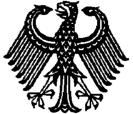

Image 2: page=2, size=339x174, format=png, bytes=116,885


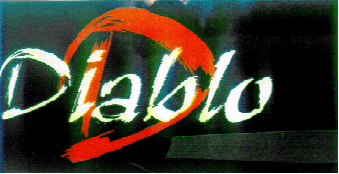

In [4]:
from IPython.display import Image, display

images = [
    (page.page_number, elem.image)
    for page in doc.pages
    for elem in page.elements
    if elem.type == ContentType.IMAGE and elem.image and elem.image.data
]

print(f"Display image instances (adapter): {len(images)}")

max_to_show = 12
for idx, (page_no, img) in enumerate(images[:max_to_show], start=1):
    print(
        f"Image {idx}: page={page_no}, size={img.width}x{img.height}, "
        f"format={img.format}, bytes={len(img.data):,}"
    )
    display(Image(data=img.data, format=img.format.lower()))

if len(images) > max_to_show:
    print(f"... and {len(images) - max_to_show} more display image(s).")
elif not images:
    print("No display-worthy images were found in this sample PDF.")

## 4 — Parse from bytes

In [5]:
raw_bytes = (FIXTURES / PDF_FILE_NAME).read_bytes()
print(f"PDF size: {len(raw_bytes):,} bytes")

doc_bytes = parser.parse_bytes(raw_bytes, source_name=PDF_FILE_NAME)
print(f"Pages: {doc_bytes.metadata.page_count}")
print(f"Elements on page 1: {len(doc_bytes.pages[0].elements)}")

PDF size: 377,902 bytes
MuPDF error: format error: No default Layer config

MuPDF error: format error: No common ancestor in structure tree



2026-04-01 12:00:20,199 - INFO - Extracted 10 pages from '24030-03_06072004.pdf'


Pages: 10
Elements on page 1: 13


## 5 — JSON serialisation (`to_dict`)

In [6]:
d = doc.to_dict()

# Pretty-print the first page only (to keep output manageable)
first_page = {"metadata": d["metadata"], "pages": [d["pages"][0]]}
print(json.dumps(first_page, indent=2, ensure_ascii=False))

{
  "metadata": {
    "title": "Microsoft Word - 24030_03 06.07.2004.doc",
    "author": null,
    "subject": null,
    "creator": "Acrobat PDFMaker 7.0.5 für Word",
    "producer": "Acrobat Distiller 7.0.5 (Windows)",
    "page_count": 10
  },
  "pages": [
    {
      "page_number": 1,
      "width": 595.219970703125,
      "height": 842.0,
      "elements": [
        {
          "type": "text",
          "text_block": {
            "content": "BPatG 154",
            "font_name": "ArialMT",
            "font_size": 11.0
          }
        },
        {
          "type": "text",
          "text_block": {
            "content": "6.70",
            "font_name": "ArialMT",
            "font_size": 11.0
          }
        },
        {
          "type": "text",
          "text_block": {
            "content": "BUNDESPATENTGERICHT",
            "font_name": "Arial-BoldMT",
            "font_size": 22.0
          }
        },
        {
          "type": "text",
          "text_block": {
   

## 6 — Configuration: disable images & tables

In [7]:
cfg = PdfParserConfig(extract_images=False, extract_tables=False)
text_only_parser = create_pdf_parser(logger, config=cfg)

doc_text = text_only_parser.parse_file(FIXTURES / PDF_FILE_NAME)
for page in doc_text.pages:
    types = [e.type.value for e in page.elements]
    print(f"Page {page.page_number}: {types}")
    # Should only contain 'text' — no 'image' or 'table'

MuPDF error: format error: No default Layer config



2026-04-01 12:00:20,246 - INFO - Extracted 10 pages from '24030-03_06072004.pdf'


Page 1: ['text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text']
Page 2: ['text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text']
Page 3: ['text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text']
Page 4: ['text', 'text', 'text', 'text', 'text', 'text', 'text']
Page 5: ['text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text']
Page 6: ['text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text']
Page 7: ['text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'text', '